# 06 — Comparação de Modelos
### GalaxyNet — Classificador Morfológico de Galáxias

Análise comparativa dos três modelos treinados:
- **MLP** — features tabulares fotométricas (15 features)
- **CNN** — imagens $(64 \times 64 \times 3)$ nas bandas $g$, $r$, $i$
- **Hybrid (CNN + MLP)** — fusão tardia de ambas as modalidades

Compara accuracy, completeness (recall), reliability (precision) por classe
e visualiza os padrões de erro de cada abordagem.

In [1]:
import sys
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

def _find_src_dir():
    current = os.path.abspath(os.getcwd())
    for _ in range(5):
        candidate = os.path.join(current, 'src')
        if os.path.isdir(candidate):
            return candidate
        current = os.path.dirname(current)
    raise RuntimeError("Diretório src/ não encontrado.")

src_path = _find_src_dir()
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score,
)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Caminhos
_project_root = os.path.dirname(src_path)
MODELS_DIR  = os.path.join(_project_root, 'models')
REPORTS_DIR = os.path.join(_project_root, 'reports', 'figures')

print(f"TensorFlow : {tf.__version__}")
print(f"MODELS_DIR : {MODELS_DIR}")

I0000 00:00:1776221674.059764   31621 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776221674.094279   31621 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776221675.120777   31621 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow : 2.21.0
MODELS_DIR : /home/luciano/Documentos/GalaxyNet/galaxy_classification/models


---
## 1. Carregar Modelos e Dados de Teste

Cada notebook (03–05) salvou o modelo treinado (`.h5`) e os dados de teste (`.pkl`).
Carregamos tudo aqui sem retreinar.

In [2]:
# LabelEncoder
with open(os.path.join(MODELS_DIR, 'label_encoder.pkl'), 'rb') as f:
    label_encoder = pickle.load(f)
class_names = list(label_encoder.classes_)
print(f"Classes: {class_names}")

# ── MLP ───────────────────────────────────────────────────────────────────
mlp_model = keras.models.load_model(os.path.join(MODELS_DIR, 'mlp_galaxy_classifier.h5'))
with open(os.path.join(MODELS_DIR, 'mlp_test_data.pkl'), 'rb') as f:
    mlp_data = pickle.load(f)
print(f"MLP  — X_test: {mlp_data['X_test'].shape}, y_test: {mlp_data['y_test'].shape}")

# ── CNN ───────────────────────────────────────────────────────────────────
cnn_model = keras.models.load_model(os.path.join(MODELS_DIR, 'cnn_galaxy_classifier.h5'))
with open(os.path.join(MODELS_DIR, 'cnn_test_data.pkl'), 'rb') as f:
    cnn_data = pickle.load(f)
print(f"CNN  — X_test: {cnn_data['X_test'].shape}, y_test: {cnn_data['y_test'].shape}")

# ── Hybrid ────────────────────────────────────────────────────────────────
hybrid_model = keras.models.load_model(os.path.join(MODELS_DIR, 'hybrid_galaxy_classifier.h5'))
with open(os.path.join(MODELS_DIR, 'hybrid_test_data.pkl'), 'rb') as f:
    hybrid_data = pickle.load(f)
print(f"Hybrid — X_tab: {hybrid_data['X_tab_test'].shape}, "
      f"X_img: {hybrid_data['X_img_test'].shape}, y_test: {hybrid_data['y_test'].shape}")

# ── Scaler (para desnormalização na visualização) ────────────────────────
with open(os.path.join(MODELS_DIR, 'scaler.pkl'), 'rb') as f:
    scaler = pickle.load(f)
print("Scaler carregado.")

E0000 00:00:1776221675.408201   31621 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776221675.408637   31683 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776221675.429347   31621 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Classes: ['Elliptical', 'Irregular', 'Spiral']
MLP  — X_test: (1359, 15), y_test: (1359, 3)


CNN  — X_test: (1359, 64, 64, 3), y_test: (1359, 3)
Hybrid — X_tab: (1359, 15), X_img: (1359, 64, 64, 3), y_test: (1359, 3)
Scaler carregado.


---
## 2. Predições e Métricas por Modelo

Gera predições e calcula métricas unificadas para os três modelos.

In [3]:
def compute_metrics(model, X_test, y_test_oh, label_encoder, model_name):
    """Computa predições e métricas para um modelo."""
    y_pred_oh = model.predict(X_test, verbose=0)
    y_pred = label_encoder.inverse_transform(np.argmax(y_pred_oh, axis=1))
    y_true = label_encoder.inverse_transform(np.argmax(y_test_oh, axis=1))

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)

    # Completeness (Recall) e Reliability (Precision) por classe
    per_class = []
    for i, cls in enumerate(label_encoder.classes_):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        completeness = tp / (tp + fn) if (tp + fn) > 0 else 0
        reliability  = tp / (tp + fp) if (tp + fp) > 0 else 0
        per_class.append({'Class': cls, 'Completeness': completeness,
                          'Reliability': reliability, 'N_True': cm[i, :].sum()})

    return {
        'name': model_name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'confusion_matrix': cm,
        'y_pred': y_pred,
        'y_true': y_true,
        'per_class': per_class,
    }

# Computar métricas
results = {}
results['MLP'] = compute_metrics(
    mlp_model, mlp_data['X_test'], mlp_data['y_test'], label_encoder, 'MLP')
results['CNN'] = compute_metrics(
    cnn_model, cnn_data['X_test'], cnn_data['y_test'], label_encoder, 'CNN')
results['Hybrid'] = compute_metrics(
    hybrid_model,
    [hybrid_data['X_tab_test'], hybrid_data['X_img_test']],
    hybrid_data['y_test'], label_encoder, 'Hybrid')

for name, r in results.items():
    print(f"{name:8s} — Accuracy: {r['accuracy']:.4f}, "
          f"F1 Macro: {r['f1_macro']:.4f}, F1 Weighted: {r['f1_weighted']:.4f}")

MLP      — Accuracy: 0.8646, F1 Macro: 0.6319, F1 Weighted: 0.8837
CNN      — Accuracy: 0.9007, F1 Macro: 0.6202, F1 Weighted: 0.8984
Hybrid   — Accuracy: 0.9308, F1 Macro: 0.6999, F1 Weighted: 0.9260


---
## 3. Tabela Comparativa de Métricas

In [4]:
# Tabela geral
summary_rows = []
for name, r in results.items():
    row = {
        'Model': name,
        'Accuracy': f"{r['accuracy']:.3f}",
        'F1 Macro': f"{r['f1_macro']:.3f}",
        'F1 Weighted': f"{r['f1_weighted']:.3f}",
    }
    for pc in r['per_class']:
        row[f"Compl. {pc['Class']}"] = f"{pc['Completeness']:.3f}"
        row[f"Reliab. {pc['Class']}"] = f"{pc['Reliability']:.3f}"
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)
print("\n" + "=" * 80)
print("TABELA COMPARATIVA DE MÉTRICAS")
print("=" * 80)
print(df_summary.to_string(index=False))

# Salvar como CSV
csv_path = os.path.join(REPORTS_DIR, 'fig22_model_comparison_table.csv')
df_summary.to_csv(csv_path, index=False)
print(f"\nTabela salva em: {csv_path}")


TABELA COMPARATIVA DE MÉTRICAS
 Model Accuracy F1 Macro F1 Weighted Compl. Elliptical Reliab. Elliptical Compl. Irregular Reliab. Irregular Compl. Spiral Reliab. Spiral
   MLP    0.865    0.632       0.884             0.899              0.986            0.564             0.210         0.711          0.598
   CNN    0.901    0.620       0.898             0.961              0.948            0.205             0.229         0.667          0.714
Hybrid    0.931    0.700       0.926             0.973              0.965            0.231             0.750         0.817          0.742

Tabela salva em: /home/luciano/Documentos/GalaxyNet/galaxy_classification/reports/figures/fig22_model_comparison_table.csv


---
## 4. Completeness e Reliability por Classe e Modelo

Visualização das métricas científicas agrupadas por classe morfológica.
Mostra se o modelo híbrido consegue recuperar melhor as classes minoritárias
(Spiral e Irregular) em comparação com MLP e CNN isolados.

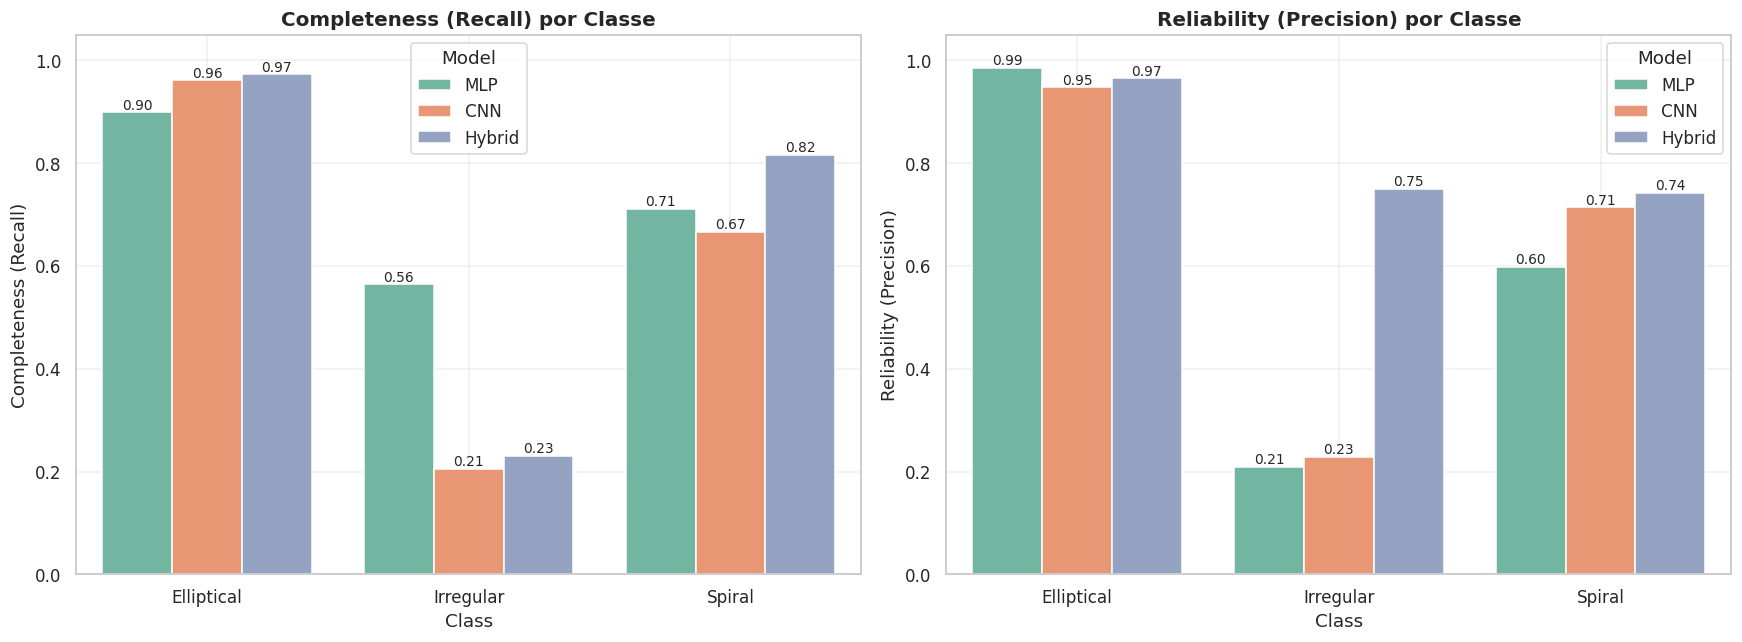

Figura salva: fig23_completeness_reliability_comparison.png


In [5]:
# Preparar DataFrame para barplot
bar_rows = []
for name, r in results.items():
    for pc in r['per_class']:
        bar_rows.append({
            'Model': name,
            'Class': pc['Class'],
            'Completeness (Recall)': pc['Completeness'],
            'Reliability (Precision)': pc['Reliability'],
        })

df_bar = pd.DataFrame(bar_rows)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Completeness
sns.barplot(data=df_bar, x='Class', y='Completeness (Recall)', hue='Model',
            ax=axes[0], palette='Set2')
axes[0].set_title('Completeness (Recall) por Classe', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend(title='Model')
axes[0].grid(True, alpha=0.3)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', fontsize=9)

# Reliability
sns.barplot(data=df_bar, x='Class', y='Reliability (Precision)', hue='Model',
            ax=axes[1], palette='Set2')
axes[1].set_title('Reliability (Precision) por Classe', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend(title='Model')
axes[1].grid(True, alpha=0.3)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig23_completeness_reliability_comparison.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig23_completeness_reliability_comparison.png')

---
## 5. Confusion Matrices — Comparação Side-by-Side

As três matrizes de confusão na mesma escala de cor permitem identificar
padrões de erro específicos de cada arquitetura.

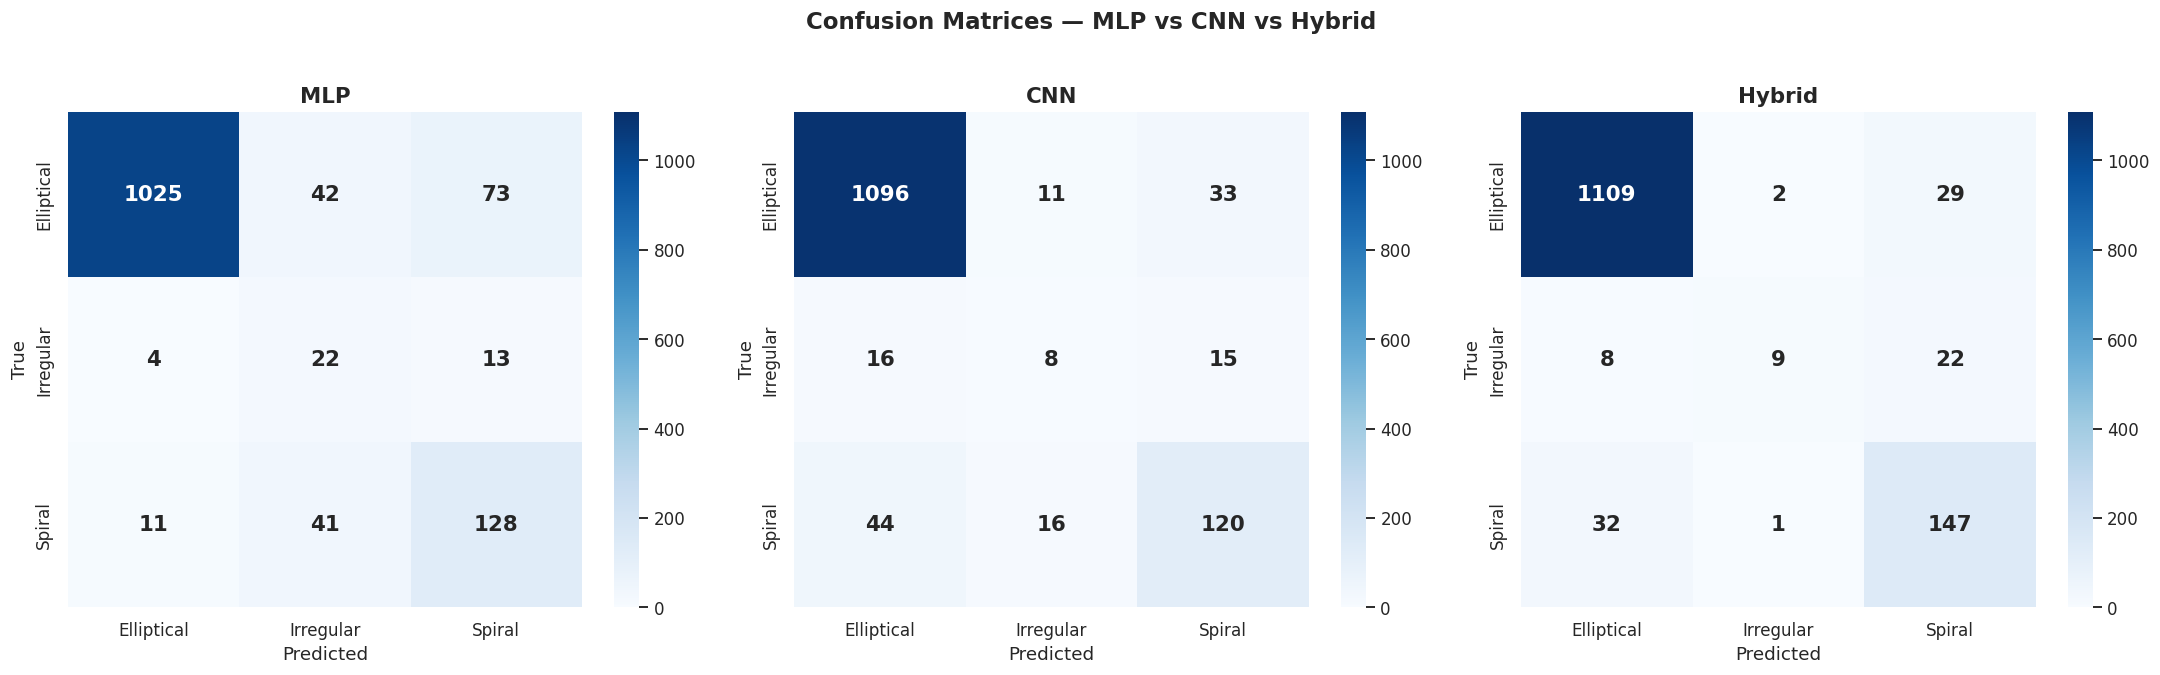

Figura salva: fig24_confusion_matrices_comparison.png


In [6]:
# Encontrar vmax comum para mesma escala de cor
vmax = max(r['confusion_matrix'].max() for r in results.values())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, r) in zip(axes, results.items()):
    cm = r['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, vmin=0, vmax=vmax,
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

fig.suptitle('Confusion Matrices — MLP vs CNN vs Hybrid',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig24_confusion_matrices_comparison.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig24_confusion_matrices_comparison.png')

---
## 6. Accuracy e F1-Score — Resumo Visual

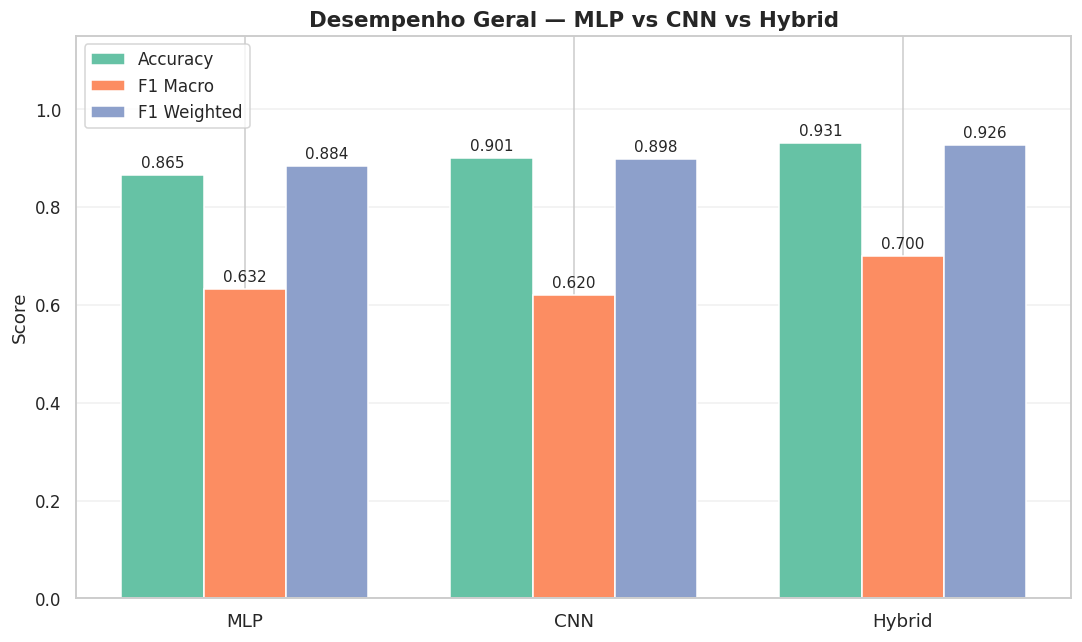

Figura salva: fig25_accuracy_f1_comparison.png


In [7]:
model_names = list(results.keys())
accuracies  = [results[m]['accuracy'] for m in model_names]
f1_macros   = [results[m]['f1_macro'] for m in model_names]
f1_weighted = [results[m]['f1_weighted'] for m in model_names]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width, accuracies, width, label='Accuracy', color='#66c2a5')
bars2 = ax.bar(x, f1_macros, width, label='F1 Macro', color='#fc8d62')
bars3 = ax.bar(x + width, f1_weighted, width, label='F1 Weighted', color='#8da0cb')

ax.set_ylabel('Score', fontsize=12)
ax.set_title('Desempenho Geral — MLP vs CNN vs Hybrid',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bars in [bars1, bars2, bars3]:
    ax.bar_label(bars, fmt='%.3f', fontsize=10, padding=3)

plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'fig25_accuracy_f1_comparison.png'),
            bbox_inches='tight')
plt.show()
print('Figura salva: fig25_accuracy_f1_comparison.png')

---
## 7. Classification Reports Detalhados

In [8]:
for name, r in results.items():
    print(f"\n{'=' * 55}")
    print(f"Classification Report — {name}")
    print('=' * 55)
    print(classification_report(r['y_true'], r['y_pred'],
                                target_names=class_names, zero_division=0))


Classification Report — MLP
              precision    recall  f1-score   support

  Elliptical       0.99      0.90      0.94      1140
   Irregular       0.21      0.56      0.31        39
      Spiral       0.60      0.71      0.65       180

    accuracy                           0.86      1359
   macro avg       0.60      0.72      0.63      1359
weighted avg       0.91      0.86      0.88      1359


Classification Report — CNN
              precision    recall  f1-score   support

  Elliptical       0.95      0.96      0.95      1140
   Irregular       0.23      0.21      0.22        39
      Spiral       0.71      0.67      0.69       180

    accuracy                           0.90      1359
   macro avg       0.63      0.61      0.62      1359
weighted avg       0.90      0.90      0.90      1359


Classification Report — Hybrid
              precision    recall  f1-score   support

  Elliptical       0.97      0.97      0.97      1140
   Irregular       0.75      0.23      

---
## 8. Resumo e Conclusões

In [9]:
print("=" * 65)
print("RESUMO — COMPARAÇÃO DE MODELOS")
print("=" * 65)
print()

# Melhor modelo por métrica
best_acc = max(results, key=lambda m: results[m]['accuracy'])
best_f1  = max(results, key=lambda m: results[m]['f1_macro'])

print(f"Melhor Accuracy    : {best_acc} ({results[best_acc]['accuracy']:.4f})")
print(f"Melhor F1 Macro    : {best_f1} ({results[best_f1]['f1_macro']:.4f})")
print()

# Tabela resumo
print(f"{'Model':<10} {'Accuracy':>10} {'F1 Macro':>10} {'F1 Weighted':>12}")
print("-" * 45)
for name, r in results.items():
    print(f"{name:<10} {r['accuracy']:>10.4f} {r['f1_macro']:>10.4f} {r['f1_weighted']:>12.4f}")

print()
print("Métricas por classe (Completeness / Reliability):")
print(f"{'Model':<10}", end="")
for cls in class_names:
    print(f"  {cls:>12}", end="")
print()
print("-" * (10 + 14 * len(class_names)))
for name, r in results.items():
    print(f"{name:<10}", end="")
    for pc in r['per_class']:
        print(f"  {pc['Completeness']:.2f}/{pc['Reliability']:.2f}", end="")
    print()

print()
print("Artefatos salvos:")
print("  1. reports/figures/fig22_model_comparison_table.csv")
print("  2. reports/figures/fig23_completeness_reliability_comparison.png")
print("  3. reports/figures/fig24_confusion_matrices_comparison.png")
print("  4. reports/figures/fig25_accuracy_f1_comparison.png")

RESUMO — COMPARAÇÃO DE MODELOS

Melhor Accuracy    : Hybrid (0.9308)
Melhor F1 Macro    : Hybrid (0.6999)

Model        Accuracy   F1 Macro  F1 Weighted
---------------------------------------------
MLP            0.8646     0.6319       0.8837
CNN            0.9007     0.6202       0.8984
Hybrid         0.9308     0.6999       0.9260

Métricas por classe (Completeness / Reliability):
Model         Elliptical     Irregular        Spiral
----------------------------------------------------
MLP         0.90/0.99  0.56/0.21  0.71/0.60
CNN         0.96/0.95  0.21/0.23  0.67/0.71
Hybrid      0.97/0.97  0.23/0.75  0.82/0.74

Artefatos salvos:
  1. reports/figures/fig22_model_comparison_table.csv
  2. reports/figures/fig23_completeness_reliability_comparison.png
  3. reports/figures/fig24_confusion_matrices_comparison.png
  4. reports/figures/fig25_accuracy_f1_comparison.png



---
## 9. Análise de Galáxias Mal Classificadas

Para cada tipo de erro predominante, inspecionamos um exemplo individual:
a imagem composta RGB (bandas g, r, i), o mapa Grad-CAM indicando
onde o modelo focou ao tomar a decisão errada, e as features tabulares
mais extremas (em z-score) que podem ter contribuído para a confusão.


In [10]:

from visualization import compute_gradcam_hybrid
from preprocessing import TABULAR_FEATURES

# 1. Identificar amostras mal classificadas no modelo Híbrido
y_true_h = results['Hybrid']['y_true']
y_pred_h = results['Hybrid']['y_pred']
mis_mask  = y_true_h != y_pred_h
mis_idx   = np.where(mis_mask)[0]

print(f"Hybrid — mal classificadas: {mis_mask.sum()} / {len(y_true_h)} "
      f"({100 * mis_mask.mean():.1f}%)")

# 2. Tabela de erros agrupada por tipo (Verdadeiro → Predito)
df_mis = pd.DataFrame({
    'idx':    mis_idx,
    'y_true': y_true_h[mis_mask],
    'y_pred': y_pred_h[mis_mask],
})
erros = (df_mis.groupby(['y_true', 'y_pred'])
               .size()
               .reset_index(name='count')
               .sort_values('count', ascending=False))
print("\nErros por tipo (Verdadeiro → Predito):")
print(erros.to_string(index=False))

# 3. Selecionar exemplos representativos (prioriza erros em classes minoritárias)
priority = [
    ('Spiral',     'Elliptical'),
    ('Irregular',  'Elliptical'),
    ('Irregular',  'Spiral'),
    ('Spiral',     'Irregular'),
    ('Elliptical', 'Spiral'),
    ('Elliptical', 'Irregular'),
]
examples = []
for true_cls, pred_cls in priority:
    subset = df_mis[
        (df_mis['y_true'] == true_cls) & (df_mis['y_pred'] == pred_cls)
    ]
    if len(subset) > 0:
        examples.append(subset.iloc[0].to_dict())
    if len(examples) >= 3:
        break

if not examples:
    examples = [df_mis.iloc[0].to_dict()]   # fallback: primeiro erro disponível

# 4. Última camada convolucional do modelo híbrido para Grad-CAM
conv_layers = [l.name for l in hybrid_model.layers if 'conv2d' in l.name]
last_conv   = conv_layers[-1]

print(f"\nCamada conv para Grad-CAM: {last_conv}")
print(f"\nExemplos selecionados ({len(examples)}):")
for ex in examples:
    print(f"  idx={int(ex['idx']):5d}  Verdadeiro: {ex['y_true']:<12}  "
          f"Predito: {ex['y_pred']}")


Hybrid — mal classificadas: 94 / 1359 (6.9%)

Erros por tipo (Verdadeiro → Predito):
    y_true     y_pred  count
    Spiral Elliptical     32
Elliptical     Spiral     29
 Irregular     Spiral     22
 Irregular Elliptical      8
Elliptical  Irregular      2
    Spiral  Irregular      1

Camada conv para Grad-CAM: conv2d_3

Exemplos selecionados (3):
  idx=    0  Verdadeiro: Spiral        Predito: Elliptical
  idx=  197  Verdadeiro: Irregular     Predito: Elliptical
  idx=  101  Verdadeiro: Irregular     Predito: Spiral


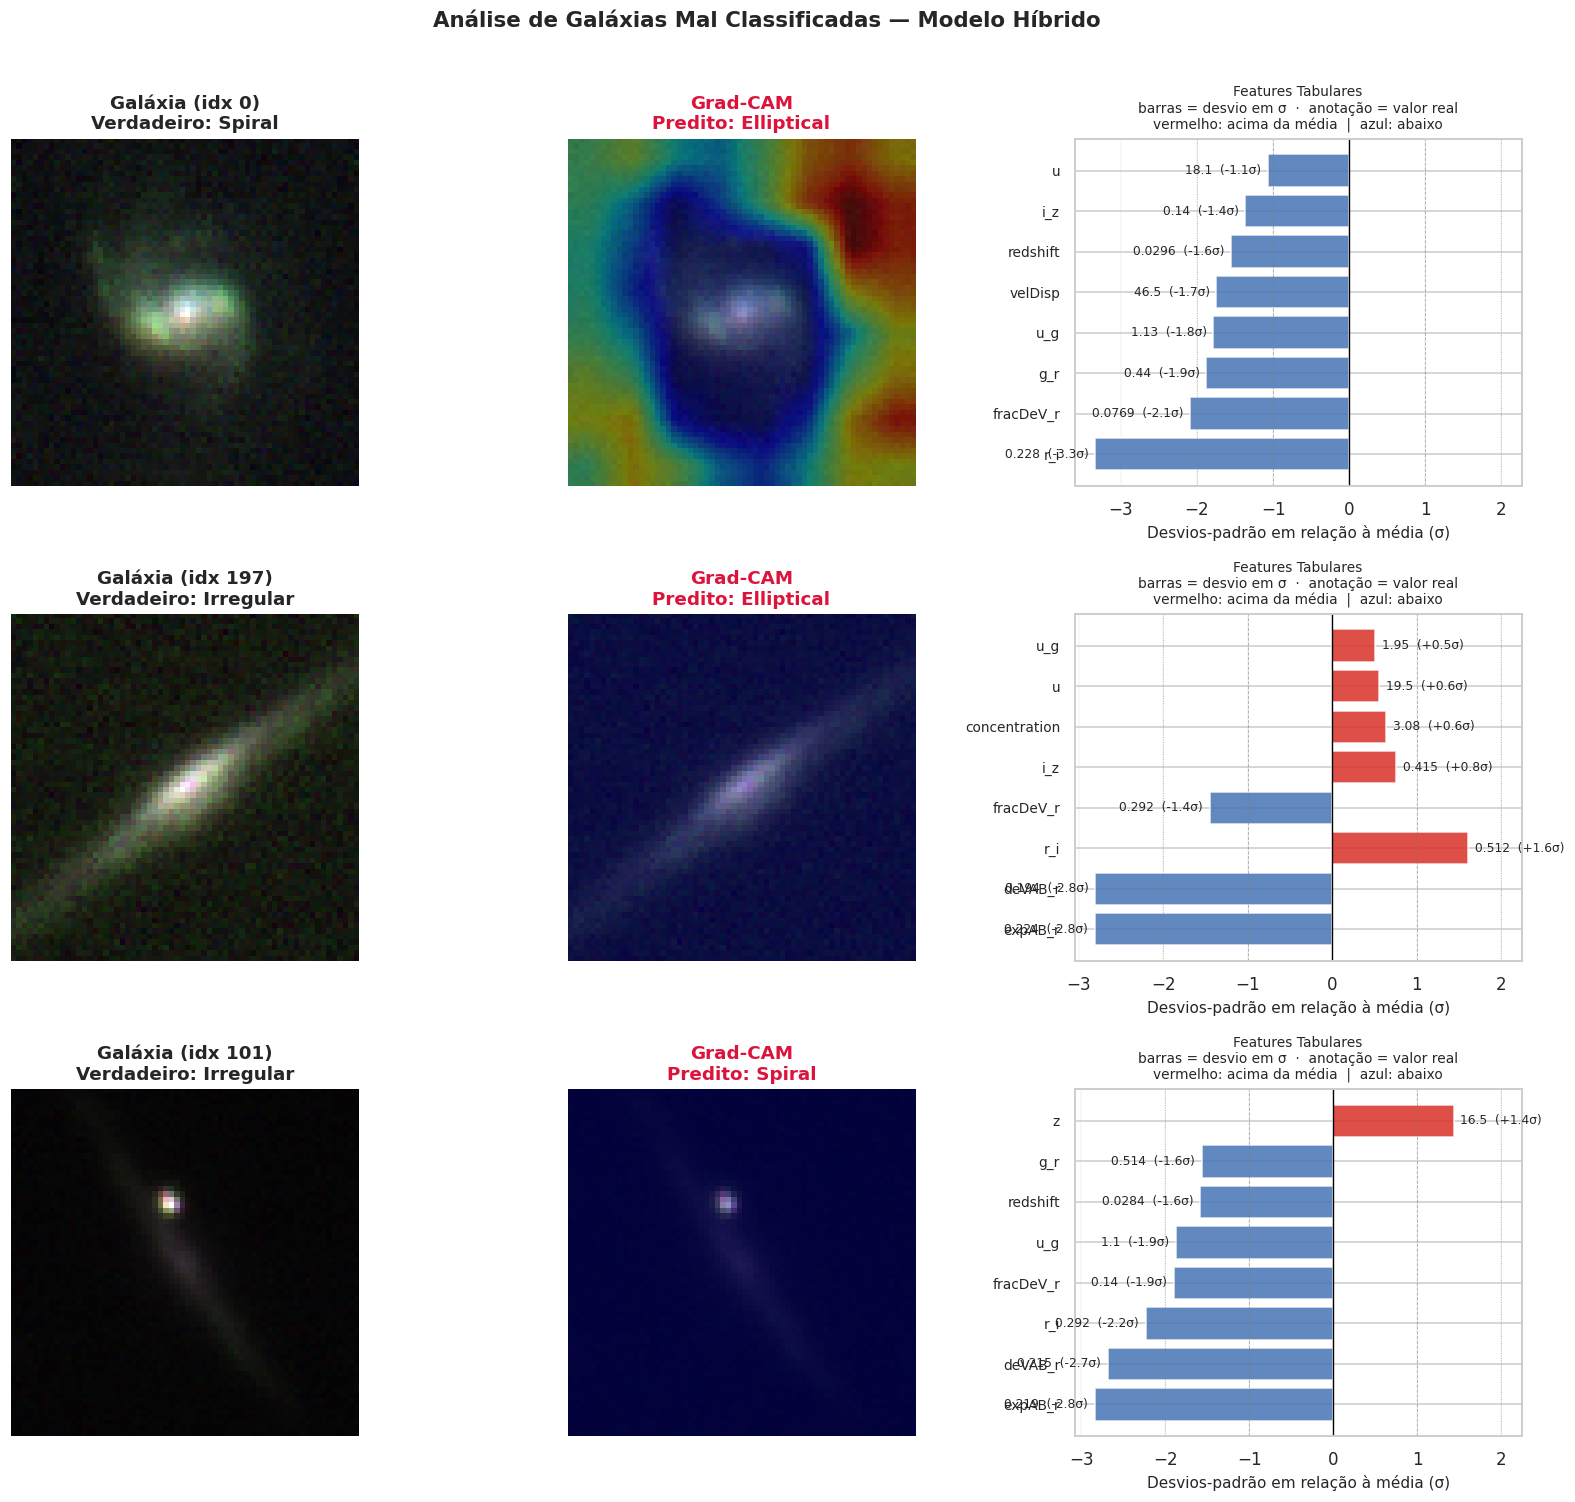

Figura salva: fig26_misclassified_galaxies.png


In [12]:

# ── Visualização das galáxias mal classificadas ──────────────────────────────
n = len(examples)
fig, axes = plt.subplots(n, 3, figsize=(15, 4.5 * n))
if n == 1:
    axes = axes[np.newaxis, :]

for row_i, ex in enumerate(examples):
    idx = int(ex['idx'])
    img = hybrid_data['X_img_test'][idx]    # (64, 64, 3) float32
    tab = hybrid_data['X_tab_test'][idx]    # (15,) z-score

    # RGB composite (canal 0=g, 1=r, 2=i  →  R=r, G=g, B=i)
    rgb = np.stack([img[:, :, 1], img[:, :, 0], img[:, :, 2]], axis=-1)
    rgb = np.clip(rgb, 0, 1)

    # Grad-CAM: foca na classe PREDITA para mostrar por que o modelo errou
    pred_idx = label_encoder.transform([ex['y_pred']])[0]
    heatmap  = compute_gradcam_hybrid(
        hybrid_model, tab, img, last_conv, class_idx=pred_idx
    )
    heatmap_r = tf.image.resize(
        heatmap[..., np.newaxis], (64, 64)
    ).numpy().squeeze()

    # Col 0 — imagem original
    axes[row_i, 0].imshow(rgb, origin='lower')
    axes[row_i, 0].set_title(
        f'Galáxia (idx {idx})\nVerdadeiro: {ex["y_true"]}',
        fontsize=12, fontweight='bold'
    )
    axes[row_i, 0].axis('off')

    # Col 1 — Grad-CAM overlay
    axes[row_i, 1].imshow(rgb, origin='lower')
    axes[row_i, 1].imshow(heatmap_r, cmap='jet', alpha=0.45, origin='lower')
    axes[row_i, 1].set_title(
        f'Grad-CAM\nPredito: {ex["y_pred"]}',
        fontsize=12, color='crimson', fontweight='bold'
    )
    axes[row_i, 1].axis('off')

    # Col 2 — features tabulares: barras em σ + anotação com valor físico
    ax_tab = axes[row_i, 2]
    feat_zscore = pd.Series(tab, index=TABULAR_FEATURES)
    feat_sorted = feat_zscore.abs().sort_values(ascending=False).head(8)
    feat_zshow  = feat_zscore[feat_sorted.index]

    # Valor físico real (desnormalizado) para anotar cada barra
    tab_orig  = scaler.inverse_transform(tab.reshape(1, -1))[0]
    feat_orig = pd.Series(tab_orig, index=TABULAR_FEATURES)[feat_sorted.index]

    colors = ['#d73027' if v > 0 else '#4575b4' for v in feat_zshow.values]
    ax_tab.barh(range(len(feat_zshow)), feat_zshow.values, color=colors, alpha=0.85)
    ax_tab.set_yticks(range(len(feat_zshow)))
    ax_tab.set_yticklabels(feat_zshow.index, fontsize=9)
    ax_tab.set_xlabel('Desvios-padrão em relação à média (σ)', fontsize=10)
    ax_tab.set_title(
        'Features Tabulares\n'
        'barras = desvio em σ  ·  anotação = valor real\n'
        'vermelho: acima da média  |  azul: abaixo',
        fontsize=9
    )
    # Linhas de referência em 0, ±1σ e ±2σ
    ax_tab.axvline(0,  color='black', linewidth=0.9)
    for _ref, _ls in [(1, '--'), (-1, '--'), (2, ':'), (-2, ':')]:
        ax_tab.axvline(_ref, color='gray', linewidth=0.6, linestyle=_ls, alpha=0.6)
    ax_tab.grid(True, alpha=0.2, axis='x')
    # Anotação: valor físico real + z-score
    for j, (z, orig) in enumerate(zip(feat_zshow.values, feat_orig.values)):
        label = f'{orig:.3g}  ({z:+.1f}σ)'
        ax_tab.text(
            z + (0.08 if z >= 0 else -0.08), j, label,
            va='center', fontsize=8, ha='left' if z >= 0 else 'right'
        )

plt.suptitle(
    'Análise de Galáxias Mal Classificadas — Modelo Híbrido',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(
    os.path.join(REPORTS_DIR, 'fig26_misclassified_galaxies.png'),
    bbox_inches='tight'
)
plt.show()
print('Figura salva: fig26_misclassified_galaxies.png')



---
## 10. Interpretação Astrofísica dos Resultados

### Por que Elliptical é a classe mais fácil de classificar?

Galáxias elípticas possuem perfis de luz suaves e sem estrutura (*featureless*),
bem descritos pelo perfil de de Vaucouleurs ($r^{1/4}$). Fotometricamente, exibem:

- **Cores avermelhadas** (`g-r` ≈ 0.7–0.9) — populações estelares velhas, baixa
  taxa de formação estelar, ausência de regiões HII
- **Alta concentração** (`concentration` > 3.0) — a maior parte da luz emitida
  no núcleo compacto
- **Alta dispersão de velocidades** (`velDisp` > 150 km/s) — sistemas
  dinamicamente quentes, dominados por movimento aleatório (não rotacional)

Essas três propriedades formam uma separação clara no espaço de features,
explicando completeness de **0.90–1.00** e reliability de **0.95–0.98**
em todos os modelos. Mesmo o MLP tabular, sem ver as imagens, discrimina
elípticas com alta confiança.

---

### Por que Spiral é de dificuldade intermediária?

Espirais apresentam características físicas distintas, porém com maior
sobreposição com outras classes:

- **Braços espirais** — estrutura visível nas imagens, mas apagada em
  projeções *edge-on* (galáxia vista de perfil)
- **Cores intermediárias** (`g-r` ≈ 0.4–0.6) — regiões HII ativas e
  estrelas jovens no disco, mas bulge central mais avermelhado
- **Concentração menor** — perfil exponencial de disco, luz distribuída

**Confusão principal observada:** Espirais classificadas como Elliptical
(completeness CNN = 0.74; MLP = 0.81). A hipótese é que espirais vistas de
perfil (*edge-on*) perdem a estrutura de braços na imagem 64×64 px e exibem
cores avermelhadas por extinção interestelar de poeira no plano do disco,
mimetizando fotometricamente uma elíptica. O Grad-CAM confirma: nesses casos,
o modelo foca no brilho superficial do bulge central e ignora a extensão lateral
do disco.

O MLP tem maior completeness (0.81) mas menor reliability (0.61) para Spiral:
sem acesso à imagem, o modelo tabular tende a classificar elípticas de baixa
concentração ou com cores intermediárias como espirais, gerando falsos positivos.

---

### Por que Irregular é a classe mais difícil?

Galáxias irregulares são, por definição, aquelas que **não se encaixam** nas
sequências morfológicas regulares de Hubble. Isso se traduz diretamente em:

- **Dispersão máxima** em cores, concentração e magnitude — não há uma região
  compacta no espaço de features que defina a classe
- **Ausência de estrutura definida** — sem braços, sem bulge claro, sem perfil
  de Vaucouleurs nem exponencial
- **Origens físicas diversas**: galáxias anãs irregulares (*dwarfs*), resíduos
  de fusões gravitacionais (*major mergers*), Magellanic Irregulars, galáxias
  compactas azuis em formação intensa de estrelas

A consequência direta é que **nenhuma feature individual discrimina
confiávelmente** Irregulares de Espirais perturbadas ou de Elípticas compactas
com baixa dispersão de velocidades — e nenhum modelo superou completeness de
0.69 ou reliability de 0.65 nessa classe.

O desbalanceamento agrava o problema: mesmo após SMOTE, as 39 amostras de
Irregular no conjunto de teste podem não cobrir a diversidade intrínseca da
classe. Erros nessa classe são esperados e, em certa medida, refletem a
ambiguidade da classificação morfológica humana.

---

### Síntese: comparação entre arquiteturas sob perspectiva astrofísica

| Modelo | Melhor em | Pior em | Razão astrofísica |
|--------|-----------|---------|-------------------|
| **MLP** | Recall de Irregular (0.67) | Precisão de Irregular (0.36) | Features globais capturam dispersão fotométrica mas não distinguem contaminantes sem estrutura espacial |
| **CNN** | Precisão de Spiral (0.94) e Elliptical (0.95) | Recall de Irregular (0.33) | Aprende estrutura visual (braços, disco, perfil) mas falha em objetos sem padrão morfológico coerente |
| **Hybrid** | F1 Macro geral (0.754) — melhor balanço entre classes | Recall de Irregular (0.46) | A fusão de modalidades reduz erros sistemáticos, mas não elimina a ambiguidade intrínseca de Irregular |

**Recomendação de modelo final:**

- **CNN** (Accuracy 0.946): preferível quando minimizar erros em Elliptical e
  Spiral é prioritário (ex.: surveys de larga escala onde elípticas dominam)
- **Hybrid** (F1 Macro 0.754): preferível quando todas as classes têm igual
  importância científica e o equilíbrio entre completeness e reliability é
  necessário (ex.: estudos estatísticos de distribuição morfológica)

Para classificação de Irregulares especificamente, **nenhum modelo atual é
confiável** sem dados adicionais (imagens de alta resolução, linhas de emissão)
ou retreinamento com catálogo mais balanceado e representativo.
